In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

data_dir = '/content/gdrive/MyDrive/NLP Project/data/'

Mounted at /content/gdrive


In [2]:
!pip install datasets
!pip install transformers
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.2 MB/s eta 0:00:00


In [3]:
## This code here just makes it so we don't need an API

import os
os.environ["WANDB_DISABLED"] = "true"

In [4]:
import numpy as np
# Ensure data_dir is set correctly
data_dir = '/content/gdrive/MyDrive/NLP Project/data/'

x_train_path = data_dir + "X_train.txt"
x_test_path = data_dir + "X_test.txt"
y_train_path = data_dir + "y_train.txt"
y_test_path = data_dir + "y_test.txt"

# Load X_train (sentences) as text
with open(x_train_path, 'r') as f:
    X_train = f.read().splitlines()

# Load X_test (sentences) as text
with open(x_test_path, 'r') as f:
    X_test = f.read().splitlines()

# Load y_train (labels) as text and convert to int
with open(y_train_path, 'r') as f:
    y_train = [line.strip() for line in f.read().splitlines()]

# Load y_test (labels) as text and convert to int
with open(y_test_path, 'r') as f:
    y_test = [line.strip() for line in f.read().splitlines()]

print(f"Loaded X_train samples: {len(X_train)}")
print(f"Loaded X_test samples: {len(X_test)}")
print(f"Loaded y_train samples: {len(y_train)}")
print(f"Loaded y_test samples: {len(y_test)}")

# Define unique_labels here so it's available for subsequent cells
unique_labels = sorted(list(set(y_train)))

Loaded X_train samples: 15629
Loaded X_test samples: 3766
Loaded y_train samples: 15629
Loaded y_test samples: 3766


In [5]:
import pandas as pd
from datasets import Dataset, DatasetDict

# Create pandas DataFrames from the loaded data
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

# Convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Create a DatasetDict to hold both train and test datasets
hf_dataset = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

print("Hugging Face Dataset structure:")
print(hf_dataset)
print(f"Number of unique labels: {len(unique_labels)}")
print(f"Unique labels: {unique_labels}")

# Map labels to integers for model training
label_to_id = {label: i for i, label in enumerate(unique_labels)}
id_to_label = {i: label for i, label in enumerate(unique_labels)}

def encode_labels(batch):
    return {'label': [label_to_id[label] for label in batch['label']]}

hf_dataset = hf_dataset.map(encode_labels, batched=True)

print("Dataset after label encoding:")
print(hf_dataset['train'][0]) # Display first sample of training data with encoded label

Hugging Face Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 15629
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3766
    })
})
Number of unique labels: 6
Unique labels: ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']


Map:   0%|          | 0/15629 [00:00<?, ? examples/s]

Map:   0%|          | 0/3766 [00:00<?, ? examples/s]

Dataset after label encoding:
{'text': 'however, low interest rates and a slowdown in global trade pressured revenue at deutsche’s other divisions, such as those for corporate and retail clients.', 'label': 5}


In [7]:
from transformers import AutoTokenizer

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

# Apply the tokenization function to both datasets
tokenized_hf_dataset = hf_dataset.map(tokenize_function, batched=True)

print("Tokenized dataset structure:")
print(tokenized_hf_dataset)
print("Example of tokenized input (first training sample):")
print(tokenized_hf_dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/15629 [00:00<?, ? examples/s]

Map:   0%|          | 0/3766 [00:00<?, ? examples/s]

Tokenized dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15629
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3766
    })
})
Example of tokenized input (first training sample):
{'text': 'however, low interest rates and a slowdown in global trade pressured revenue at deutsche’s other divisions, such as those for corporate and retail clients.', 'label': 5, 'input_ids': [101, 2174, 1010, 2659, 3037, 6165, 1998, 1037, 4030, 7698, 1999, 3795, 3119, 25227, 6599, 2012, 11605, 1521, 1055, 2060, 5908, 1010, 2107, 2004, 2216, 2005, 5971, 1998, 7027, 7846, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [8]:
from transformers import DataCollatorWithPadding

# Initialize the data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Data collator initialized.")

Data collator initialized.


In [9]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Load the model for sequence classification, specifying the number of labels
num_labels = len(unique_labels)
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

print(f"Model '{model.base_model_prefix}' loaded with {num_labels} labels.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model 'distilbert' loaded with 6 labels.


In [10]:
from evaluate import load
import numpy as np

# Load accuracy and f1 metrics
accuracy_metric = load("accuracy")
f1_metric = load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1_macro = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]

    return {"accuracy": accuracy, "f1_macro": f1_macro}

print("Metrics 'accuracy' and 'f1' loaded and compute_metrics function defined.")

Metrics 'accuracy' and 'f1' loaded and compute_metrics function defined.


In [11]:
import os

# Define output directory for saving model checkpoints and results
# Change to a local temporary directory for faster I/O during training
output_dir = "/tmp/results"
os.makedirs(output_dir, exist_ok=True)

# Define TrainingArguments
training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    report_to="none",
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_hf_dataset["train"],
    eval_dataset=tokenized_hf_dataset["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Training arguments and Trainer initialized.")
print(f"Output directory: {output_dir}")

Training arguments and Trainer initialized.
Output directory: /tmp/results


In [12]:
# Start training the model
print("Starting model training...")
trainer.train()
print("Training complete.")

# Evaluate the trained model on the test set
print("Evaluating the model...")
results = trainer.evaluate()
print("Evaluation results:")
print(results)

Starting model training...


Step,Training Loss
500,0.863032
1000,0.643867
1500,0.472448
2000,0.479358
2500,0.340835
3000,0.311647
3500,0.236955
4000,0.217481
4500,0.175124


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
Evaluating the model...


Evaluation results:
{'eval_loss': 0.7846031188964844, 'eval_accuracy': 0.7774827403080191, 'eval_f1_macro': 0.7191770452689222, 'eval_runtime': 2.3846, 'eval_samples_per_second': 1579.329, 'eval_steps_per_second': 98.97, 'epoch': 5.0}


In [13]:
import numpy as np
from sklearn.metrics import classification_report

# Install scikit-learn if not already installed
!pip install scikit-learn

# Get predictions from the trainer on the test dataset
predictions_output = trainer.predict(tokenized_hf_dataset["test"])

# Extract predictions (logits) and true labels
logits = predictions_output.predictions
true_labels = predictions_output.label_ids

# Convert logits to predicted label IDs
predicted_labels_ids = np.argmax(logits, axis=-1)

# Map integer labels back to original string labels ('A', 'B', 'C') for better readability
true_labels_mapped = [id_to_label[label_id] for label_id in true_labels]
predicted_labels_mapped = [id_to_label[label_id] for label_id in predicted_labels_ids]

# Generate a classification report
print("\nDetailed Classification Report per Label:")
print(classification_report(true_labels_mapped, predicted_labels_mapped, labels=unique_labels, target_names=unique_labels))



Detailed Classification Report per Label:
              precision    recall  f1-score   support

          A1       0.91      0.91      0.91       961
          A2       0.65      0.61      0.63       485
          B1       0.64      0.72      0.68       740
          B2       0.61      0.63      0.62       507
          C1       0.59      0.53      0.56       128
          C2       0.95      0.88      0.92       945

    accuracy                           0.78      3766
   macro avg       0.73      0.71      0.72      3766
weighted avg       0.78      0.78      0.78      3766



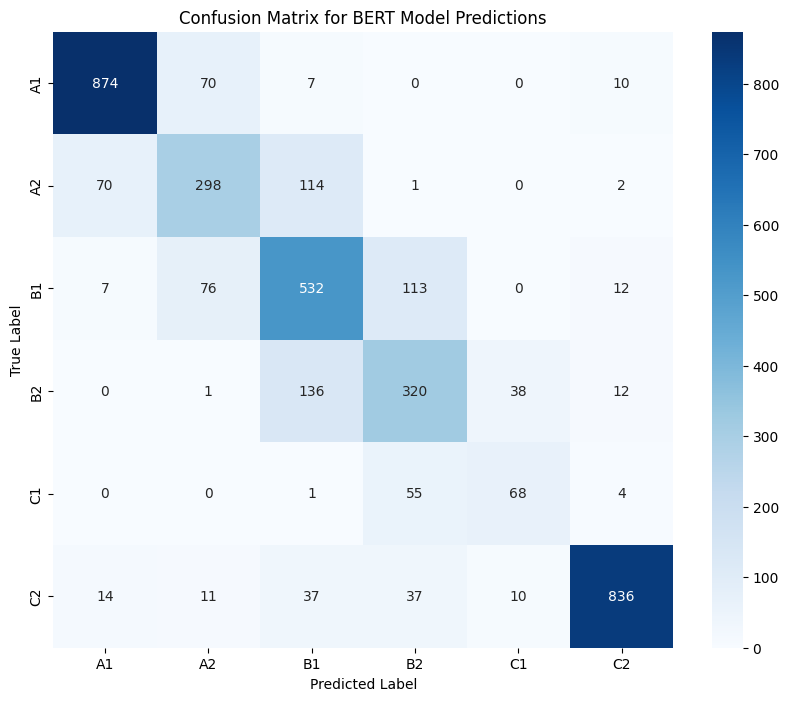

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(true_labels_mapped, predicted_labels_mapped, labels=unique_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix for BERT Model Predictions')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()